
# ANÁLISES CLÍNICAS DO SINAN


 Este notebook realiza análises agregadas relacionadas
 aos sinais clínicos e às doenças pré-existentes
 registradas nos casos de dengue do SINAN.
#
## Principais objetivos:
 - analisar a frequência dos sinais clínicos;
 - analisar a frequência das doenças pré-existentes;
 - comparar esses registros entre as UFs;
 - avaliar a completude das variáveis clínicas;
 - produzir artefatos analíticos para etapas posteriores.

**Resumo** da estrutura do notebook

1. Montagem do Drive
2. Imports
3. Configuração
4. Carregamento do SINAN enriquecido
5. Verificação das variáveis clínicas
6. Definição dos sinais clínicos analisados
7. Definição das doenças pré-existentes analisadas
8. Frequência dos sinais clínicos no Brasil
9. Frequência dos sinais clínicos por UF
10. Frequência das doenças pré-existentes no Brasil
11. Frequência das doenças pré-existentes por UF
12. Completude das variáveis clínicas
13. Visualizações
14. Produtos clínicos finais
15. Inventário dos produtos
16. Salvamento
17. Validação dos arquivos


## 1 - Montagem do drive

In [1]:
from google.colab import drive
import os

drive.mount("/content/drive")

Mounted at /content/drive


##2 - Imports

In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 3. Configuração

In [3]:
# ============================================================
# CONFIGURAÇÃO
# ============================================================

ANO = 2026

PASTA_BASE = Path(
    "/content/drive/MyDrive/Doutorado/arbovirus_rag"
)

PASTA_PROCESSED = (
    PASTA_BASE
    / "data_processed"
    / "SINAN"
    / str(ANO)
)

PASTA_ANALISES = (
    PASTA_BASE
    / "data_analytics"
    / "SINAN"
    / str(ANO)
)

PASTA_ANALISES.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_ENTRADA = (
    PASTA_PROCESSED
    / f"sinan_dengue_{ANO}_enriquecido.parquet"
)

# ============================================================
# DIRETÓRIO DE SAÍDA DOS PRODUTOS clínicos
# ============================================================

PASTA_SAIDA = (
    PASTA_BASE
    / "data_analytics"
    / "SINAN"
    / str(ANO)
    / "clinicas"
)

PASTA_SAIDA.mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Pasta de saída:\n{PASTA_SAIDA}"
)

print(f"Ano: {ANO}")
print(f"Entrada: {ARQUIVO_ENTRADA}")
print(f"Saída: {PASTA_ANALISES}")


Pasta de saída:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026/clinicas
Ano: 2026
Entrada: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_processed/SINAN/2026/sinan_dengue_2026_enriquecido.parquet
Saída: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026


## 4. Carregar o dataframe enriquecido

In [4]:
# ============================================================
# CARREGAMENTO
# ============================================================

df = pd.read_parquet(
    ARQUIVO_ENTRADA
)

print(
    f"Registros carregados: {len(df):,}"
)

print(
    f"Quantidade de variáveis: {df.shape[1]}"
)

display(
    df.head()
)

Registros carregados: 444,266
Quantidade de variáveis: 171


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W,SEMANA_EPIDEMIOLOGICA,ANO_SEM_NOT,UF_NAME,SOROTIPO_ANALITICO,HOSPITALIZ_ANALITICO,EVOLUCAO_ANALITICO,SOROTIPO_DECODED,HOSPITALIZ_DECODED,EVOLUCAO_DECODED,FEBRE_DECODED,MIALGIA_DECODED,CEFALEIA_DECODED,EXANTEMA_DECODED,VOMITO_DECODED,NAUSEA_DECODED,DOR_COSTAS_DECODED,CONJUNTVIT_DECODED,ARTRITE_DECODED,ARTRALGIA_DECODED,PETEQUIA_N_DECODED,LEUCOPENIA_DECODED,LACO_DECODED,DOR_RETRO_DECODED,DIABETES_DECODED,HEMATOLOG_DECODED,HEPATOPAT_DECODED,RENAL_DECODED,HIPERTENSA_DECODED,ACIDO_PEPT_DECODED,AUTO_IMUNE_DECODED,TPAUTOCTO_DECODED,COUFINF_NORMALIZADO,COMUNINF_NORMALIZADO,CODIGO_MUNICIPIO_6,CODIGO_MUNICIPIO_7,MUNICIPIO_NAME,UF_RESIDENCIA,CODIGO_UF_IBGE,REGIAO,POPULACAO_2022,LATITUDE,LONGITUDE,IS_CAPITAL,PIB_PER_CAPITA_2021,COD_MUNICIPIO_PROVAVEL_INFECCAO,MUNICIPIO_PROVAVEL_INFECCAO,UF_PROVAVEL_INFECCAO,COD_UF_PROVAVEL_INFECCAO,REGIAO_PROVAVEL_INFECCAO,UF_PROVAVEL_INFECCAO_CONSISTENTE
0,2,A90,2026-05-19,202620,2026,32,320400,32001,2448653,2026-05-14,202619,1978,4048,F,5,1,8,32,320400,32001,1,2026-05-18,251605,1,1,2,1,2,1,1,2,2,1,1,1,2,1,2,2,2,2,2,2,2,None,None,None,0,0,0,None,4,2026-05-18,1,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,1,0,1,1,None,2026-05-25,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-11-08,0,0,0,20,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Não,Sim,Não,Sim,Sim,Não,Não,Sim,Sim,Sim,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Sim,<NA>,<NA>,320400,3204005,Pancas,ES,32,Sudeste,18893.0,-19.2229,-40.8534,0.0,16755.0,<NA>,None,None,<NA>,None,None
1,2,A90,2026-01-05,202601,2026,32,320500,32002,2499495,2026-01-04,202601,1984,4041,F,5,4,5,32,320500,32002,1,2026-01-05,0,1,1,1,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,1,2,2,None,None,None,0,0,0,None,4,2026-01-05,2,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Sim,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Sim,<NA>,<NA>,320500,3205002,Serra,ES,32,Sudeste,520653.0,-20.1210,-40.3074,0.0,8471034.0,<NA>,None,None,<NA>,None,None
2,2,A90,2026-01-05,202601,2026,32,320500,32002,2522772,2026-01-05,202601,1991,4034,F,5,2,6,32,320500,32002,1,2026-01-05,322215,1,2,1,2,1,2,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,None,None,None,0,0,0,None,0,1920-01-05,2,None,4,None,0,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Não,Sim,Não,Sim,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,<NA>,<NA>,320500,3205002,Serra,ES,32,Sudeste,520653.0,-20.1210,-40.3074,0.0,8471034.0,<NA>,None,None,<NA>,None,None
3,2,A90,2026-01-05,202601,2026,32,320500,32002,7838131,2026-

##5 e 6. verificação rápida das variáveis essenciais:

In [5]:
# ============================================================
# VERIFICAÇÃO DAS VARIÁVEIS NECESSÁRIAS ÀS ANÁLISES
# ============================================================

# ============================================================
# SINAIS CLÍNICOS
# ============================================================

SINAIS_CLINICOS = [
    "FEBRE_DECODED",
    "MIALGIA_DECODED",
    "CEFALEIA_DECODED",
    "EXANTEMA_DECODED",
    "VOMITO_DECODED",
    "NAUSEA_DECODED",
    "DOR_COSTAS_DECODED",
    "CONJUNTVIT_DECODED",
    "ARTRITE_DECODED",
    "ARTRALGIA_DECODED",
    "PETEQUIA_N_DECODED",
    "LEUCOPENIA_DECODED",
    "LACO_DECODED",
    "DOR_RETRO_DECODED"
]

# ============================================================
# DOENÇAS PRÉ-EXISTENTES
# ============================================================

DOENCAS_PREEXISTENTES = [
    "DIABETES_DECODED",
    "HEMATOLOG_DECODED",
    "HEPATOPAT_DECODED",
    "RENAL_DECODED",
    "HIPERTENSA_DECODED",
    "ACIDO_PEPT_DECODED",
    "AUTO_IMUNE_DECODED"
]

In [6]:
# ============================================================
# VERIFICAÇÃO DAS VARIÁVEIS CLÍNICAS
# ============================================================

VARIAVEIS_CLINICAS = (
    [
        "NU_ANO",
        "SG_UF_NOT",
        "UF_NAME"
    ]
    + SINAIS_CLINICOS
    + DOENCAS_PREEXISTENTES
)

verificacao_clinica = pd.DataFrame({
    "VARIAVEL": VARIAVEIS_CLINICAS,
    "EXISTE": [
        coluna in df.columns
        for coluna in VARIAVEIS_CLINICAS
    ]
})

display(verificacao_clinica)

,VARIAVEL,EXISTE
0,NU_ANO,True
1,SG_UF_NOT,True
2,UF_NAME,True
3,FEBRE_DECODED,True
4,MIALGIA_DECODED,True
5,CEFALEIA_DECODED,True
6,EXANTEMA_DECODED,True
7,VOMITO_DECODED,True
8,NAUSEA_DECODED,True
9,DOR_COSTAS_DECODED,True


In [7]:
variaveis_ausentes = (
    verificacao_clinica.loc[
        ~verificacao_clinica["EXISTE"],
        "VARIAVEL"
    ]
    .tolist()
)

if variaveis_ausentes:
    raise ValueError(
        "Variáveis clínicas não encontradas: "
        + ", ".join(variaveis_ausentes)
    )

print(
    "OK — todas as variáveis necessárias "
    "às análises clínicas estão disponíveis."
)

OK — todas as variáveis necessárias às análises clínicas estão disponíveis.


## 8. Frequência dos sinais clínicos no Brasil

In [8]:
# ============================================================
# RÓTULOS DOS SINAIS CLÍNICOS
# ============================================================

ROTULOS_SINAIS = {
    "FEBRE_DECODED": "Febre",
    "MIALGIA_DECODED": "Mialgia",
    "CEFALEIA_DECODED": "Cefaleia",
    "EXANTEMA_DECODED": "Exantema",
    "VOMITO_DECODED": "Vômito",
    "NAUSEA_DECODED": "Náusea",
    "DOR_COSTAS_DECODED": "Dor nas costas",
    "CONJUNTVIT_DECODED": "Conjuntivite",
    "ARTRITE_DECODED": "Artrite",
    "ARTRALGIA_DECODED": "Artralgia",
    "PETEQUIA_N_DECODED": "Petéquias",
    "LEUCOPENIA_DECODED": "Leucopenia",
    "LACO_DECODED": "Prova do laço",
    "DOR_RETRO_DECODED": "Dor retro-orbital"
}

In [9]:
# ============================================================
# FREQUÊNCIA DOS SINAIS CLÍNICOS — BRASIL
# ============================================================

resultados_sintomas_brasil = []

TOTAL_REGISTROS = len(df)

for variavel in SINAIS_CLINICOS:

    serie = df[variavel]

    total_sim = (serie == "Sim").sum()
    total_nao = (serie == "Não").sum()

    total_avaliaveis = (
        total_sim
        + total_nao
    )

    total_ausentes = (
        TOTAL_REGISTROS
        - total_avaliaveis
    )

    percentual_sim = (
        total_sim
        / total_avaliaveis
        * 100
        if total_avaliaveis > 0
        else 0
    )

    percentual_ausentes = (
        total_ausentes
        / TOTAL_REGISTROS
        * 100
        if TOTAL_REGISTROS > 0
        else 0
    )

    resultados_sintomas_brasil.append({
        "VARIAVEL": variavel,
        "SINAL_CLINICO": ROTULOS_SINAIS[variavel],
        "TOTAL_REGISTROS": TOTAL_REGISTROS,
        "AVALIAVEIS": total_avaliaveis,
        "SIM": total_sim,
        "NAO": total_nao,
        "AUSENTES": total_ausentes,
        "PERCENTUAL_SIM": round(
            percentual_sim,
            2
        ),
        "PERCENTUAL_AUSENTES": round(
            percentual_ausentes,
            2
        )
    })


sintomas_brasil = pd.DataFrame(
    resultados_sintomas_brasil
)

sintomas_brasil = (
    sintomas_brasil
    .sort_values(
        "PERCENTUAL_SIM",
        ascending=False
    )
    .reset_index(drop=True)
)

display(sintomas_brasil)

,VARIAVEL,SINAL_CLINICO,TOTAL_REGISTROS,AVALIAVEIS,SIM,NAO,AUSENTES,PERCENTUAL_SIM,PERCENTUAL_AUSENTES
0,FEBRE_DECODED,Febre,444266,428673,378134,50539,15593,88.21,3.51
1,MIALGIA_DECODED,Mialgia,444266,428673,339154,89519,15593,79.12,3.51
2,CEFALEIA_DECODED,Cefaleia,444266,428673,337325,91348,15593,78.69,3.51
3,NAUSEA_DECODED,Náusea,444266,428673,176360,252313,15593,41.14,3.51
4,VOMITO_DECODED,Vômito,444266,428673,123997,304676,15593,28.93,3.51
5,DOR_RETRO_DECODED,Dor retro-orbital,444266,428673,122819,305854,15593,28.65,3.51
6,DOR_COSTAS_DECODED,Dor nas costas,444266,428673,107302,321371,15593,25.03,3.51
7,ARTRALGIA_DECODED,Artralgia,444266,428673,78961,349712,15593,18.42,3.51
8,EXANTEMA_DECODED,Exantema,444266,428673,42524,386149,15593,9.92,3.51
9,ARTRITE_DECODED,Artrite,444266,428673,36240,392433,15593,8.45,3.51


O que significa PERCENTUAL_SIM?

Estamos calculando:

$$ \%Sim = \frac{\text{Sim}} {\text{Sim}+\text{Não}} \times100 $$

Portanto, o percentual é calculado entre os registros avaliáveis, e não sobre todos os registros do SINAN.

Por exemplo, suponha:

Total de registros = 100.000

Febre:

Sim     = 70.000

Não     = 10.000

Ausente = 20.000

Então:

$$ \frac{70.000}{80.000}\times100=87,5\% $$

Podemos dizer:

Entre os registros com informação disponível sobre febre, 87,5% apresentaram registro de febre.

Isso é mais preciso do que dizer simplesmente que “87,5% dos casos apresentaram febre”.

## 9. Frequência dos sinais clínicos por UF

Agora fazemos exatamente o mesmo cálculo, mas separando por UF de notificação.


In [10]:
# ============================================================
# FREQUÊNCIA DOS SINAIS CLÍNICOS POR UF
# ============================================================

resultados_sintomas_uf = []

for (codigo_uf, nome_uf), grupo_uf in df.groupby(
    [
        "SG_UF_NOT",
        "UF_NAME"
    ],
    dropna=False
):

    total_registros_uf = len(grupo_uf)

    for variavel in SINAIS_CLINICOS:

        serie = grupo_uf[variavel]

        total_sim = (
            serie == "Sim"
        ).sum()

        total_nao = (
            serie == "Não"
        ).sum()

        total_avaliaveis = (
            total_sim
            + total_nao
        )

        total_ausentes = (
            total_registros_uf
            - total_avaliaveis
        )

        percentual_sim = (
            total_sim
            / total_avaliaveis
            * 100
            if total_avaliaveis > 0
            else 0
        )

        percentual_ausentes = (
            total_ausentes
            / total_registros_uf
            * 100
            if total_registros_uf > 0
            else 0
        )

        resultados_sintomas_uf.append({

            "SG_UF_NOT": codigo_uf,

            "UF_NAME": nome_uf,

            "VARIAVEL": variavel,

            "SINAL_CLINICO":
                ROTULOS_SINAIS[variavel],

            "TOTAL_REGISTROS":
                total_registros_uf,

            "AVALIAVEIS":
                total_avaliaveis,

            "SIM":
                total_sim,

            "NAO":
                total_nao,

            "AUSENTES":
                total_ausentes,

            "PERCENTUAL_SIM":
                round(
                    percentual_sim,
                    2
                ),

            "PERCENTUAL_AUSENTES":
                round(
                    percentual_ausentes,
                    2
                )
        })


sintomas_uf = pd.DataFrame(
    resultados_sintomas_uf
)

display(
    sintomas_uf.sort_values(
        [
            "UF_NAME",
            "PERCENTUAL_SIM"
        ],
        ascending=[
            True,
            False
        ]
    )
)

,SG_UF_NOT,UF_NAME,VARIAVEL,SINAL_CLINICO,TOTAL_REGISTROS,AVALIAVEIS,SIM,NAO,AUSENTES,PERCENTUAL_SIM,PERCENTUAL_AUSENTES
14,12,Acre,FEBRE_DECODED,Febre,1832,1645,1559,86,187,94.77,10.21
16,12,Acre,CEFALEIA_DECODED,Cefaleia,1832,1645,1448,197,187,88.02,10.21
15,12,Acre,MIALGIA_DECODED,Mialgia,1832,1645,1303,342,187,79.21,10.21
20,12,Acre,DOR_COSTAS_DECODED,Dor nas costas,1832,1645,631,1014,187,38.36,10.21
19,12,Acre,NAUSEA_DECODED,Náusea,1832,1645,603,1042,187,36.66,10.21
...,...,...,...,...,...,...,...,...,...,...,...
92,17,Tocantins,ARTRITE_DECODED,Artrite,15430,14722,1070,13652,708,7.27,4.59
94,17,Tocantins,PETEQUIA_N_DECODED,Petéquias,15430,14722,1000,13722,708,6.79,4.59
95,17,Tocantins,LEUCOPENIA_DECODED,Leucopenia,15430,14722,912,13810,708,6.19,4.59
91,17,Tocantins,CONJUNTVIT_DECODED,Conjuntivite,15430,14722,345,14377,708,2.34,4.59


##10. Frequência das doenças pré-existentes no Brasil

Criar rótulos mais compreensíveis

Para cada doença pré-existente vamos distinguir:

- SIM: doença registrada como presente;

- NAO: registrada como ausente;

- AUSENTES: sem informação;

- AVALIAVEIS: SIM + NAO;

- PERCENTUAL_SIM: percentual de presença entre os registros avaliáveis;

- PERCENTUAL_AUSENTES: incompletude da variável.


Essa estrutura por UF é uma aplicação natural do groupby, que separa o DataFrame em grupos e permite calcular estatísticas para cada grupo.

In [11]:
# ============================================================
# RÓTULOS DAS DOENÇAS PRÉ-EXISTENTES
# ============================================================

ROTULOS_DOENCAS = {
    "DIABETES_DECODED": "Diabetes",
    "HEMATOLOG_DECODED": "Doença hematológica",
    "HEPATOPAT_DECODED": "Hepatopatia",
    "RENAL_DECODED": "Doença renal",
    "HIPERTENSA_DECODED": "Hipertensão arterial",
    "ACIDO_PEPT_DECODED": "Doença ácido-péptica",
    "AUTO_IMUNE_DECODED": "Doença autoimune"
}

In [12]:
# ============================================================
# FREQUÊNCIA DAS DOENÇAS PRÉ-EXISTENTES — BRASIL
# ============================================================

resultados_doencas_brasil = []

TOTAL_REGISTROS = len(df)

for variavel in DOENCAS_PREEXISTENTES:

    serie = df[variavel]

    total_sim = (
        serie == "Sim"
    ).sum()

    total_nao = (
        serie == "Não"
    ).sum()

    total_avaliaveis = (
        total_sim
        + total_nao
    )

    total_ausentes = (
        TOTAL_REGISTROS
        - total_avaliaveis
    )

    percentual_sim = (
        total_sim
        / total_avaliaveis
        * 100
        if total_avaliaveis > 0
        else 0
    )

    percentual_ausentes = (
        total_ausentes
        / TOTAL_REGISTROS
        * 100
        if TOTAL_REGISTROS > 0
        else 0
    )

    resultados_doencas_brasil.append({

        "VARIAVEL":
            variavel,

        "DOENCA_PREEXISTENTE":
            ROTULOS_DOENCAS[variavel],

        "TOTAL_REGISTROS":
            TOTAL_REGISTROS,

        "AVALIAVEIS":
            total_avaliaveis,

        "SIM":
            total_sim,

        "NAO":
            total_nao,

        "AUSENTES":
            total_ausentes,

        "PERCENTUAL_SIM":
            round(
                percentual_sim,
                2
            ),

        "PERCENTUAL_AUSENTES":
            round(
                percentual_ausentes,
                2
            )
    })


doencas_preexistentes_brasil = pd.DataFrame(
    resultados_doencas_brasil
)

doencas_preexistentes_brasil = (
    doencas_preexistentes_brasil
    .sort_values(
        "PERCENTUAL_SIM",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    doencas_preexistentes_brasil
)

,VARIAVEL,DOENCA_PREEXISTENTE,TOTAL_REGISTROS,AVALIAVEIS,SIM,NAO,AUSENTES,PERCENTUAL_SIM,PERCENTUAL_AUSENTES
0,HIPERTENSA_DECODED,Hipertensão arterial,444266,428667,33179,395488,15599,7.74,3.51
1,DIABETES_DECODED,Diabetes,444266,428668,15374,413294,15598,3.59,3.51
2,AUTO_IMUNE_DECODED,Doença autoimune,444266,428668,2761,425907,15598,0.64,3.51
3,HEMATOLOG_DECODED,Doença hematológica,444266,428669,2306,426363,15597,0.54,3.51
4,HEPATOPAT_DECODED,Hepatopatia,444266,428668,2259,426409,15598,0.53,3.51
5,RENAL_DECODED,Doença renal,444266,428668,2177,426491,15598,0.51,3.51
6,ACIDO_PEPT_DECODED,Doença ácido-péptica,444266,428668,2139,426529,15598,0.50,3.51


Como interpretar?

Suponha que para hipertensão você obtenha:

TOTAL_REGISTROS = 425.929

AVALIAVEIS      = 300.000

SIM             = 30.000

NAO             = 270.000

AUSENTES        = 125.929

PERCENTUAL_SIM  = 10,00%

Os 10% significariam:

Entre os registros com informação disponível sobre hipertensão, 10% apresentaram registro dessa condição.

Não significaria necessariamente:

10% de todos os casos de dengue tinham hipertensão.

Essa distinção é importante por causa dos registros sem informação.

## 11. Frequência das doenças pré-existentes por UF

Agora repetimos a análise dentro de cada UF de notificação:

In [13]:
# ============================================================
# FREQUÊNCIA DAS DOENÇAS PRÉ-EXISTENTES POR UF
# ============================================================

resultados_doencas_uf = []

for (codigo_uf, nome_uf), grupo_uf in df.groupby(
    [
        "SG_UF_NOT",
        "UF_NAME"
    ],
    dropna=False
):

    total_registros_uf = len(
        grupo_uf
    )

    for variavel in DOENCAS_PREEXISTENTES:

        serie = grupo_uf[variavel]

        total_sim = (
            serie == "Sim"
        ).sum()

        total_nao = (
            serie == "Não"
        ).sum()

        total_avaliaveis = (
            total_sim
            + total_nao
        )

        total_ausentes = (
            total_registros_uf
            - total_avaliaveis
        )

        percentual_sim = (
            total_sim
            / total_avaliaveis
            * 100
            if total_avaliaveis > 0
            else 0
        )

        percentual_ausentes = (
            total_ausentes
            / total_registros_uf
            * 100
            if total_registros_uf > 0
            else 0
        )

        resultados_doencas_uf.append({

            "SG_UF_NOT":
                codigo_uf,

            "UF_NAME":
                nome_uf,

            "VARIAVEL":
                variavel,

            "DOENCA_PREEXISTENTE":
                ROTULOS_DOENCAS[variavel],

            "TOTAL_REGISTROS":
                total_registros_uf,

            "AVALIAVEIS":
                total_avaliaveis,

            "SIM":
                total_sim,

            "NAO":
                total_nao,

            "AUSENTES":
                total_ausentes,

            "PERCENTUAL_SIM":
                round(
                    percentual_sim,
                    2
                ),

            "PERCENTUAL_AUSENTES":
                round(
                    percentual_ausentes,
                    2
                )
        })


doencas_preexistentes_uf = pd.DataFrame(
    resultados_doencas_uf
)

display(
    doencas_preexistentes_uf.sort_values(
        [
            "UF_NAME",
            "PERCENTUAL_SIM"
        ],
        ascending=[
            True,
            False
        ]
    )
)

,SG_UF_NOT,UF_NAME,VARIAVEL,DOENCA_PREEXISTENTE,TOTAL_REGISTROS,AVALIAVEIS,SIM,NAO,AUSENTES,PERCENTUAL_SIM,PERCENTUAL_AUSENTES
11,12,Acre,HIPERTENSA_DECODED,Hipertensão arterial,1832,1645,98,1547,187,5.96,10.21
7,12,Acre,DIABETES_DECODED,Diabetes,1832,1645,43,1602,187,2.61,10.21
9,12,Acre,HEPATOPAT_DECODED,Hepatopatia,1832,1645,7,1638,187,0.43,10.21
8,12,Acre,HEMATOLOG_DECODED,Doença hematológica,1832,1645,6,1639,187,0.36,10.21
13,12,Acre,AUTO_IMUNE_DECODED,Doença autoimune,1832,1645,6,1639,187,0.36,10.21
...,...,...,...,...,...,...,...,...,...,...,...
47,17,Tocantins,ACIDO_PEPT_DECODED,Doença ácido-péptica,15430,14722,124,14598,708,0.84,4.59
43,17,Tocantins,HEMATOLOG_DECODED,Doença hematológica,15430,14722,102,14620,708,0.69,4.59
44,17,Tocantins,HEPATOPAT_DECODED,Hepatopatia,15430,14722,92,14630,708,0.62,4.59
45,17,Tocantins,RENAL_DECODED,Doença renal,15430,14722,67,14655,708,0.46,4.59


## 13. Visualizações

PERCENTUAL_SIM, lembrando que ele representa o percentual de "Sim" entre os registros avaliáveis.

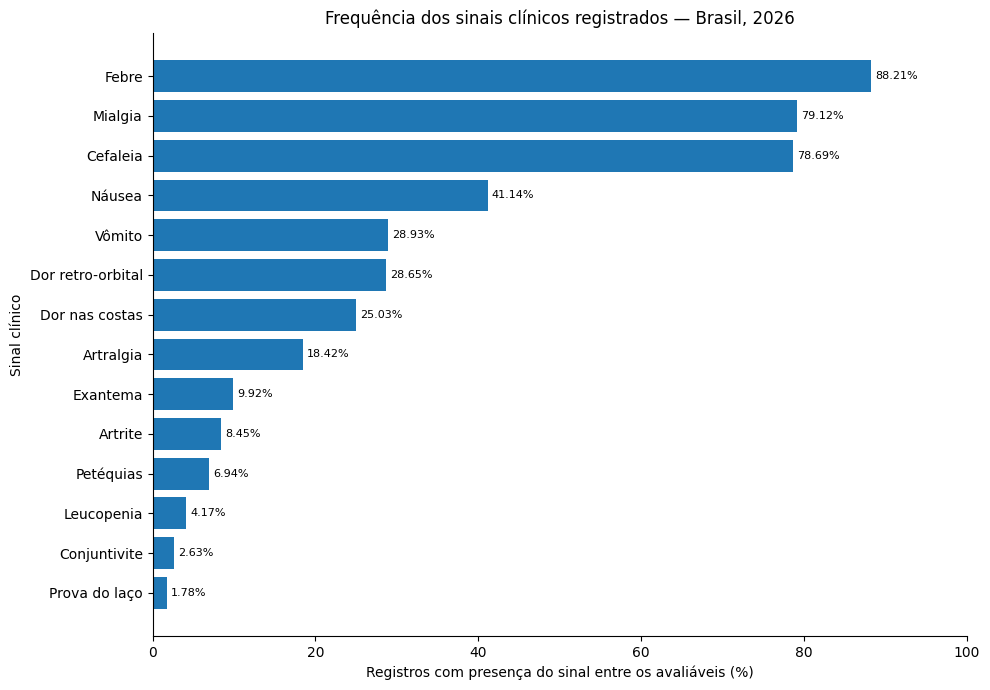

In [14]:
# ============================================================
# GRÁFICO — FREQUÊNCIA DOS SINAIS CLÍNICOS NO BRASIL
# ============================================================


import matplotlib.pyplot as plt

dados_grafico = (
    sintomas_brasil
    .sort_values(
        "PERCENTUAL_SIM",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

barras = ax.barh(
    dados_grafico["SINAL_CLINICO"],
    dados_grafico["PERCENTUAL_SIM"]
)

ax.set_title(
    f"Frequência dos sinais clínicos registrados — Brasil, {ANO}"
)

ax.set_xlabel(
    "Registros com presença do sinal entre os avaliáveis (%)"
)

ax.set_ylabel(
    "Sinal clínico"
)

ax.set_xlim(
    0,
    100
)

ax.bar_label(
    barras,
    labels=[
        f"{valor:.2f}%"
        for valor in dados_grafico["PERCENTUAL_SIM"]
    ],
    padding=3,
    fontsize=8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

Doenças pré-existentes — Brasil

Aplicamos exatamente a mesma lógica:

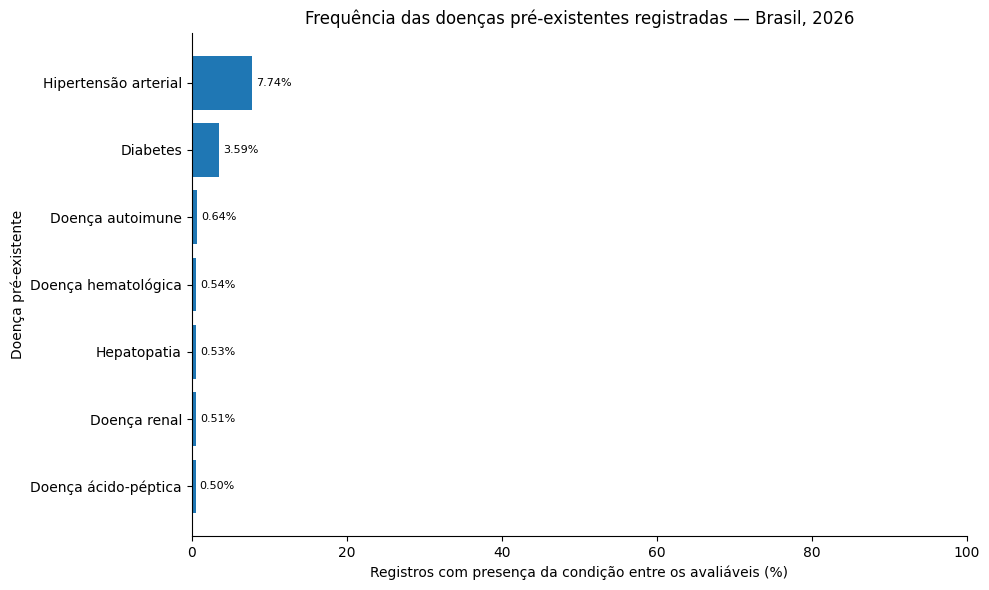

In [15]:
# ============================================================
# GRÁFICO — FREQUÊNCIA DAS DOENÇAS PRÉ-EXISTENTES NO BRASIL
# ============================================================

dados_grafico = (
    doencas_preexistentes_brasil
    .sort_values(
        "PERCENTUAL_SIM",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

barras = ax.barh(
    dados_grafico["DOENCA_PREEXISTENTE"],
    dados_grafico["PERCENTUAL_SIM"]
)

ax.set_title(
    f"Frequência das doenças pré-existentes registradas — Brasil, {ANO}"
)

ax.set_xlabel(
    "Registros com presença da condição entre os avaliáveis (%)"
)

ax.set_ylabel(
    "Doença pré-existente"
)

ax.set_xlim(
    0,
    100
)

ax.bar_label(
    barras,
    labels=[
        f"{valor:.2f}%"
        for valor in dados_grafico["PERCENTUAL_SIM"]
    ],
    padding=3,
    fontsize=8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

## 14. Produtos clínicos finais

In [16]:
# ============================================================
# PRODUTOS CLÍNICOS FINAIS
# ============================================================

PRODUTOS_CLINICOS = {

    # Frequência dos sinais clínicos no Brasil
    "sintomas_brasil":
        sintomas_brasil,

    # Frequência dos sinais clínicos por UF
    "sintomas_uf":
        sintomas_uf,

    # Frequência das doenças pré-existentes no Brasil
    "doencas_preexistentes_brasil":
        doencas_preexistentes_brasil,

    # Frequência das doenças pré-existentes por UF
    "doencas_preexistentes_uf":
        doencas_preexistentes_uf,


}


print(
    f"Produtos clínicos definidos: "
    f"{len(PRODUTOS_CLINICOS)}"
)

Produtos clínicos definidos: 4


## 15. Inventário dos produtos

Primeiro, vamos documentar semanticamente cada produto.

In [17]:
# ============================================================
# DESCRIÇÕES DOS PRODUTOS CLÍNICOS
# ============================================================

DESCRICOES_PRODUTOS_CLINICOS = {

    "sintomas_brasil":
        "Frequência dos sinais clínicos registrados nos casos "
        "de dengue, considerando os registros avaliáveis "
        "no conjunto nacional.",

    "sintomas_uf":
        "Frequência dos sinais clínicos registrados nos casos "
        "de dengue segundo UF de notificação.",

    "doencas_preexistentes_brasil":
        "Frequência das doenças pré-existentes registradas "
        "nos casos de dengue, considerando os registros "
        "avaliáveis no conjunto nacional.",

    "doencas_preexistentes_uf":
        "Frequência das doenças pré-existentes registradas "
        "nos casos de dengue segundo UF de notificação.",


}

In [18]:
# ============================================================
# INVENTÁRIO DOS PRODUTOS CLÍNICOS
# ============================================================

inventario_produtos_clinicos = []

for nome, produto in PRODUTOS_CLINICOS.items():

    inventario_produtos_clinicos.append({

        "PRODUTO":
            nome,

        "DESCRICAO":
            DESCRICOES_PRODUTOS_CLINICOS.get(
                nome,
                ""
            ),

        "REGISTROS":
            len(produto),

        "COLUNAS":
            len(produto.columns)
    })


inventario_produtos_clinicos = pd.DataFrame(
    inventario_produtos_clinicos
)

display(
    inventario_produtos_clinicos
)

,PRODUTO,DESCRICAO,REGISTROS,COLUNAS
0,sintomas_brasil,Frequência dos sinais clínicos registrados nos...,14,9
1,sintomas_uf,Frequência dos sinais clínicos registrados nos...,378,11
2,doencas_preexistentes_brasil,Frequência das doenças pré-existentes registra...,7,9
3,doencas_preexistentes_uf,Frequência das doenças pré-existentes registra...,189,11


## 16. Salvamento
Salvar os produtos em Parquet

In [19]:
# ============================================================
# SALVAMENTO DOS PRODUTOS CLÍNICOS
# ============================================================

arquivos_salvos = []

for nome, produto in PRODUTOS_CLINICOS.items():

    caminho = (
        PASTA_SAIDA
        / f"{nome}_{ANO}.parquet"
    )

    produto.to_parquet(
        caminho,
        index=False
    )

    arquivos_salvos.append(
        caminho
    )

    print(
        f"Salvo: {caminho.name}"
    )


print(
    f"\nTotal de produtos salvos: "
    f"{len(arquivos_salvos)}"
)

Salvo: sintomas_brasil_2026.parquet
Salvo: sintomas_uf_2026.parquet
Salvo: doencas_preexistentes_brasil_2026.parquet
Salvo: doencas_preexistentes_uf_2026.parquet

Total de produtos salvos: 4


Salvar o inventário

In [20]:
# ============================================================
# SALVAMENTO DO INVENTÁRIO
# ============================================================

caminho_inventario = (
    PASTA_SAIDA
    / f"inventario_produtos_clinicos_{ANO}.csv"
)

inventario_produtos_clinicos.to_csv(
    caminho_inventario,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Inventário salvo: "
    f"{caminho_inventario.name}"
)

Inventário salvo: inventario_produtos_clinicos_2026.csv


Validação dos arquivos

Aqui eu manteria exatamente o mesmo padrão dos notebooks anteriores.

Vamos verificar:

1. existência do arquivo;
2. capacidade de recarregá-lo;
3. quantidade de linhas;
4. estrutura das colunas.

In [21]:
# ============================================================
# VALIDAÇÃO DOS ARQUIVOS CLÍNICOS
# ============================================================

validacao_arquivos_clinicos = []

for nome, produto_original in PRODUTOS_CLINICOS.items():

    caminho = (
        PASTA_SAIDA
        / f"{nome}_{ANO}.parquet"
    )

    try:

        arquivo_existe = (
            caminho.exists()
        )

        produto_recarregado = (
            pd.read_parquet(
                caminho
            )
        )

        mesmas_linhas = (
            len(produto_original)
            ==
            len(produto_recarregado)
        )

        mesmas_colunas = (
            list(produto_original.columns)
            ==
            list(produto_recarregado.columns)
        )

        valido = (
            arquivo_existe
            and mesmas_linhas
            and mesmas_colunas
        )

        validacao_arquivos_clinicos.append({

            "PRODUTO":
                nome,

            "ARQUIVO_EXISTE":
                arquivo_existe,

            "REGISTROS_ORIGINAL":
                len(produto_original),

            "REGISTROS_ARQUIVO":
                len(produto_recarregado),

            "MESMOS_REGISTROS":
                mesmas_linhas,

            "MESMAS_COLUNAS":
                mesmas_colunas,

            "VALIDO":
                valido
        })

    except Exception as erro:

        validacao_arquivos_clinicos.append({

            "PRODUTO":
                nome,

            "ARQUIVO_EXISTE":
                caminho.exists(),

            "REGISTROS_ORIGINAL":
                len(produto_original),

            "REGISTROS_ARQUIVO":
                None,

            "MESMOS_REGISTROS":
                False,

            "MESMAS_COLUNAS":
                False,

            "VALIDO":
                False
        })

        print(
            f"Erro ao validar {nome}: "
            f"{erro}"
        )


validacao_arquivos_clinicos = pd.DataFrame(
    validacao_arquivos_clinicos
)

display(
    validacao_arquivos_clinicos
)

,PRODUTO,ARQUIVO_EXISTE,REGISTROS_ORIGINAL,REGISTROS_ARQUIVO,MESMOS_REGISTROS,MESMAS_COLUNAS,VALIDO
0,sintomas_brasil,True,14,14,True,True,True
1,sintomas_uf,True,378,378,True,True,True
2,doencas_preexistentes_brasil,True,7,7,True,True,True
3,doencas_preexistentes_uf,True,189,189,True,True,True


Fechamento do notebook

Por fim, eu acrescentaria uma célula de resumo:

In [22]:
# ============================================================
# RESULTADO FINAL
# ============================================================

if validacao_arquivos_clinicos["VALIDO"].all():

    print("=" * 70)
    print(
        "ANÁLISES CLÍNICAS CONCLUÍDAS COM SUCESSO"
    )
    print("=" * 70)

    print(
        f"\nProdutos gerados: "
        f"{len(PRODUTOS_CLINICOS)}"
    )

    print(
        f"Arquivos validados: "
        f"{validacao_arquivos_clinicos['VALIDO'].sum()}"
    )

    print(
        f"\nDiretório:\n"
        f"{PASTA_SAIDA}"
    )

else:

    print("=" * 70)
    print(
        "ATENÇÃO — FORAM ENCONTRADOS PROBLEMAS"
    )
    print("=" * 70)

    display(
        validacao_arquivos_clinicos[
            ~validacao_arquivos_clinicos["VALIDO"]
        ]
    )

ANÁLISES CLÍNICAS CONCLUÍDAS COM SUCESSO

Produtos gerados: 4
Arquivos validados: 4

Diretório:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026/clinicas
